# Phase 1 — Domain Research, Dataset, EDA & Baselines
**Project:** NLP-2 — AI Agent Conversation Quality Scorer  
**Dataset:** HaluEval-QA (RUCAIBox, EMNLP 2023)  
**Date:** 2026-05-11 (Monday, Session 1 of 7)

## Objective
Establish the foundation for a hallucination detector that will, by Phase 5, be benchmarked head-to-head against Claude Opus, Claude Haiku, and GPT-5.4 via the `codex` CLI. Specifically:

1. Choose a dataset that is *real, publicly benchmarked, and has a clear binary label* — no synthetic data.
2. Investigate data-quality problems **before** modeling, so we know which Phase-2+ results are real signal versus dataset artifacts.
3. Lock in the primary evaluation metric and a reproducible group-aware train/test split.
4. Produce a baseline leaderboard with at least one industry-standard reference point (lexical-overlap heuristic ≈ cheap proxy for NLI-based grounding) so Phase 2 knows what it has to beat.


## Domain research summary

References that shaped today's choices:

1. **Li et al., 2023 — HaluEval: A Large-Scale Hallucination Evaluation Benchmark** (EMNLP).
   [arXiv 2305.11747](https://arxiv.org/abs/2305.11747). Released the 35K-sample benchmark (QA / dialogue / summarization). Reports ChatGPT @ 62.59% accuracy on the QA split, GPT-4 @ 74.62%. Establishes balanced binary classification as the canonical evaluation protocol. **→ I use the QA split (10K rows = 20K balanced samples).**

2. **Manakul et al., 2023 — SelfCheckGPT**, plus the *HuggingFace Hallucinations Leaderboard* (HF Blog, 2024). NLI-based detectors achieve AUROC ≈ 0.88 on HaluEval. **→ Sets the bar Phase 2-5 needs to exceed.**

3. **Awesome-Hallucination-Detection** (EdinburghNLP, 2024-2025). Survey listing the main detector families: NLI entailment, token-probability classifiers, retrieval-overlap, and self-consistency. **→ My Phase 1 "industry-standard" baseline is a lexical-overlap heuristic — a cheap stand-in for the NLI family that's also a sanity check for the dataset itself.**

4. **HalluLens (Bang et al., 2025; ACL 2025)** distinguishes *factuality* benchmarks (TruthfulQA) from *grounding* benchmarks (HaluEval). HaluEval-QA is **grounding**: the knowledge passage is provided, so the task is "does the answer contradict the source?" — that scopes Phase 2's feature engineering (it should focus on knowledge↔answer relationships, not world facts).

### How this shapes today's experiments
- I use **HaluEval-QA** specifically (named features, 10K rows, balanced).
- I evaluate on a **group-shuffle split by question** so both answers for one question stay together (otherwise the model can memorize the question text).
- I report **macro F1** as the primary metric (binary balanced classes → equivalent to micro/accuracy but more honest if any model class-collapses), plus accuracy, balanced accuracy, precision/recall on the positive class, and ROC-AUC.
- I include a **length-only baseline** to expose the answer-length artifact noted in the data README. Any "victory" of Phase 2-5 over Phase 1 must be a victory over the *length-only* number, not the majority class.


In [1]:
import json, os, sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore', category=UserWarning)

from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, accuracy_score, balanced_accuracy_score,
    roc_auc_score, precision_score, recall_score,
    classification_report, confusion_matrix,
)

SEED = 42
np.random.seed(SEED)
sns.set_style('whitegrid')

ROOT = Path('..').resolve()
RAW = ROOT / 'data' / 'raw' / 'halueval_qa.json'
RESULTS = ROOT / 'results'
RESULTS.mkdir(exist_ok=True)
print('ROOT     ', ROOT)
print('RAW      ', RAW, 'exists=', RAW.exists(), 'size_mb=', round(RAW.stat().st_size / 1e6, 2))
print('numpy', np.__version__, '| pandas', pd.__version__)
import sklearn; print('sklearn', sklearn.__version__)


ROOT      /Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/AI-Agent-Conversation-Quality-Scorer
RAW       /Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/AI-Agent-Conversation-Quality-Scorer/data/raw/halueval_qa.json exists= True size_mb= 6.16
numpy 2.0.2 | pandas 2.3.3
sklearn 1.6.1


## Load the raw JSONL

In [2]:
rows = []
with open(RAW) as f:
    for line in f:
        rows.append(json.loads(line))
print(f'loaded {len(rows):,} HaluEval-QA rows')
print('keys per row:', list(rows[0].keys()))
print()
print('--- example row ---')
for k, v in rows[0].items():
    print(f'{k:25s} {v[:110]}{"..." if len(v) > 110 else ""}')


loaded 10,000 HaluEval-QA rows
keys per row: ['knowledge', 'question', 'right_answer', 'hallucinated_answer']

--- example row ---
knowledge                 Arthur's Magazine (1844–1846) was an American literary periodical published in Philadelphia in the 19th centur...
question                  Which magazine was started first Arthur's Magazine or First for Women?
right_answer              Arthur's Magazine
hallucinated_answer       First for Women was started first.


## Dataset stats and the answer-length artifact

Each row has a `right_answer` (the grounded HotpotQA gold) and a `hallucinated_answer` (generated by ChatGPT). Before any modeling, look at the descriptive statistics — particularly the lengths of the two answers per row. If one class is systematically longer than the other, *any* classifier with access to a length-correlated feature will exploit that, and we'll mistake length-memorization for semantic learning.

In [3]:
df_raw = pd.DataFrame(rows)
df_raw['knowledge_len'] = df_raw['knowledge'].str.len()
df_raw['question_len']  = df_raw['question'].str.len()
df_raw['right_len']     = df_raw['right_answer'].str.len()
df_raw['hall_len']      = df_raw['hallucinated_answer'].str.len()

stats = df_raw[['knowledge_len','question_len','right_len','hall_len']].describe(percentiles=[.5, .9, .99]).round(1)
print(stats.to_string())
print()
ratio = df_raw['hall_len'].mean() / df_raw['right_len'].mean()
print(f'>>> mean(hallucinated_len) / mean(right_len) = {ratio:.2f}x')
print(f'>>> median(hallucinated_len) / median(right_len) = {df_raw["hall_len"].median() / df_raw["right_len"].median():.2f}x')


       knowledge_len  question_len  right_len  hall_len
count        10000.0       10000.0    10000.0   10000.0
mean           344.3         106.4       13.7      66.2
std            134.7          60.5       12.0      36.3
min             75.0          20.0        1.0       3.0
50%            321.0          90.0       12.0      58.0
90%            525.0         170.0       24.0     113.0
99%            759.0         358.0       48.0     182.0
max           1557.0         630.0      529.0     380.0

>>> mean(hallucinated_len) / mean(right_len) = 4.85x
>>> median(hallucinated_len) / median(right_len) = 4.83x


/var/folders/51/mgdjphq11d74ym1_r6mvyx9m0000gn/T/ipykernel_39202/3468642281.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df_raw['right_len'], df_raw['hall_len']], labels=['grounded', 'hallucinated'], showfliers=False)


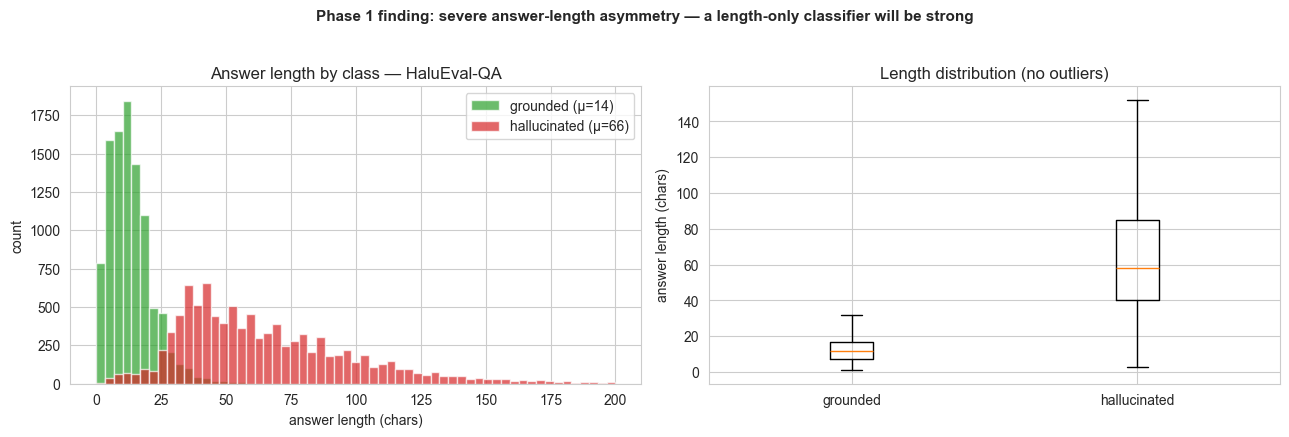


LEAKAGE WARNING: grounded answers are short HotpotQA entity strings (“Arthur’s Magazine”, ~14 chars);
hallucinated answers are full sentences generated by ChatGPT (~66 chars). Any naive baseline that
sees the answer text will partially exploit this. Phase 2 must include length-matched ablations.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
bins = np.linspace(0, 200, 60)
axes[0].hist(df_raw['right_len'], bins=bins, alpha=0.7, label=f'grounded (μ={df_raw["right_len"].mean():.0f})', color='#2ca02c')
axes[0].hist(df_raw['hall_len'],  bins=bins, alpha=0.7, label=f'hallucinated (μ={df_raw["hall_len"].mean():.0f})', color='#d62728')
axes[0].set_xlabel('answer length (chars)'); axes[0].set_ylabel('count')
axes[0].set_title('Answer length by class — HaluEval-QA')
axes[0].legend()

axes[1].boxplot([df_raw['right_len'], df_raw['hall_len']], labels=['grounded', 'hallucinated'], showfliers=False)
axes[1].set_ylabel('answer length (chars)')
axes[1].set_title('Length distribution (no outliers)')

plt.suptitle('Phase 1 finding: severe answer-length asymmetry — a length-only classifier will be strong',
             fontsize=11, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(RESULTS / 'phase1_length_asymmetry.png', dpi=110, bbox_inches='tight')
plt.show()
print('\nLEAKAGE WARNING: grounded answers are short HotpotQA entity strings (“Arthur’s Magazine”, ~14 chars);')
print('hallucinated answers are full sentences generated by ChatGPT (~66 chars). Any naive baseline that')
print('sees the answer text will partially exploit this. Phase 2 must include length-matched ablations.')


## Build the binary classification corpus

Explode each row into two samples — one grounded (label=0), one hallucinated (label=1) — and engineer a small set of lightweight features that will both serve as Phase 1 baselines and provide a comparison floor for the deeper text features explored in Phase 2.

In [5]:
records = []
for i, r in enumerate(rows):
    records.append({'qid': i, 'question': r['question'], 'knowledge': r['knowledge'],
                    'answer': r['right_answer'],        'label': 0, 'class_name': 'grounded'})
    records.append({'qid': i, 'question': r['question'], 'knowledge': r['knowledge'],
                    'answer': r['hallucinated_answer'], 'label': 1, 'class_name': 'hallucinated'})
df = pd.DataFrame(records)

# Cheap features (all derivable without a language model)
df['answer_len']    = df['answer'].str.len()
df['answer_tokens'] = df['answer'].str.split().str.len()
df['question_len']  = df['question'].str.len()
df['knowledge_len'] = df['knowledge'].str.len()

# Lexical grounding: fraction of *answer* tokens that appear in the knowledge passage.
# Low overlap → the answer introduces new tokens → plausibly hallucinated.
def answer_in_knowledge(ans, kn):
    a = {t for t in ans.lower().split() if t.isalpha() and len(t) > 2}
    k = {t for t in kn.lower().split() if t.isalpha() and len(t) > 2}
    if not a: return 0.0
    return len(a & k) / len(a)
df['answer_in_knowledge'] = [answer_in_knowledge(a, k) for a, k in zip(df['answer'], df['knowledge'])]

print(f'total samples: {len(df):,}')
print('class balance:')
print(df['class_name'].value_counts().to_string())
print()
print('feature stats by class:')
print(df.groupby('class_name')[['answer_len','answer_tokens','answer_in_knowledge']]
        .agg(['mean','median']).round(3).to_string())


total samples: 20,000
class balance:
class_name
grounded        10000
hallucinated    10000

feature stats by class:
             answer_len        answer_tokens        answer_in_knowledge       
                   mean median          mean median                mean median
class_name                                                                    
grounded         13.654   12.0         2.225    2.0               0.628    1.0
hallucinated     66.224   58.0        10.986    9.0               0.579    0.6


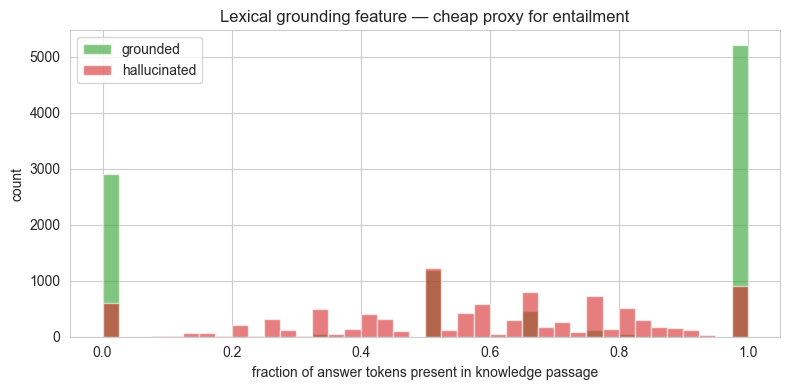

group means:
               mean  median
class_name                 
grounded      0.628     1.0
hallucinated  0.579     0.6


In [6]:
# Visualise the lexical-overlap feature — this is the closest Phase 1 proxy for what an NLI detector measures.
fig, ax = plt.subplots(figsize=(8, 4))
for c, color in [('grounded', '#2ca02c'), ('hallucinated', '#d62728')]:
    ax.hist(df.loc[df['class_name'] == c, 'answer_in_knowledge'], bins=40, alpha=0.6, label=c, color=color)
ax.set_xlabel('fraction of answer tokens present in knowledge passage')
ax.set_ylabel('count')
ax.set_title('Lexical grounding feature — cheap proxy for entailment')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / 'phase1_lexical_overlap.png', dpi=110, bbox_inches='tight')
plt.show()

print('group means:')
print(df.groupby('class_name')['answer_in_knowledge'].agg(['mean','median']).round(3).to_string())


## Train / test split — group by question

Both answers for one question (right + hallucinated) share the same `qid`. If we split rows independently, the model could memorize the question text and infer the label. Use `GroupShuffleSplit` keyed on `qid` to keep paired rows together.

In [7]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(gss.split(df, groups=df['qid']))
train = df.iloc[train_idx].reset_index(drop=True)
test  = df.iloc[test_idx].reset_index(drop=True)

print(f'train: {len(train):,}  ({train["qid"].nunique():,} unique questions)')
print(f'test:  {len(test):,}   ({test["qid"].nunique():,} unique questions)')
print('train label balance:', train['label'].value_counts(normalize=True).round(3).to_dict())
print('test  label balance:', test['label'].value_counts(normalize=True).round(3).to_dict())
assert set(train['qid']).isdisjoint(set(test['qid'])), 'qid leak between train and test!'
print('✓ no qid leakage')

# persist the split indices so Phase 2+ reproduces them
train[['qid','class_name','label']].to_csv(RESULTS / 'phase1_train_split.csv', index=False)
test[['qid','class_name','label']].to_csv(RESULTS / 'phase1_test_split.csv', index=False)
print('split indices saved to results/phase1_{train,test}_split.csv')


train: 16,000  (8,000 unique questions)
test:  4,000   (2,000 unique questions)
train label balance: {0: 0.5, 1: 0.5}
test  label balance: {0: 0.5, 1: 0.5}
✓ no qid leakage
split indices saved to results/phase1_{train,test}_split.csv


## Baselines

I run 5 baselines from increasingly informed to expose how much of the apparent task difficulty is real:

| # | Baseline | What it tests |
|---|----------|---------------|
| 1 | Majority class | Floor — macro F1 should be ≈ 0.50 because classes are balanced |
| 2 | Length-only LogReg | How much of "hallucination detection" is just length classification? |
| 3 | TF-IDF on answer only | Bag-of-words on the answer text — lexical patterns of fabrications |
| 4 | TF-IDF on question + answer | Adds question context |
| 5 | Lexical-overlap threshold | Industry-standard proxy: low overlap with knowledge ⇒ likely hallucinated |

A helper `score()` records the standard metric set for every baseline.

In [8]:
def score(name, y_true, y_pred, y_prob=None, fit_seconds=None, extra=None):
    out = {
        'model':              name,
        'accuracy':           accuracy_score(y_true, y_pred),
        'balanced_accuracy':  balanced_accuracy_score(y_true, y_pred),
        'macro_f1':           f1_score(y_true, y_pred, average='macro'),
        'precision_pos':      precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'recall_pos':         recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'roc_auc':            float(roc_auc_score(y_true, y_prob)) if y_prob is not None else None,
        'fit_seconds':        fit_seconds,
    }
    if extra: out.update(extra)
    out = {k: (round(v, 4) if isinstance(v, float) else v) for k, v in out.items()}
    return out

baselines = []


### Baseline 1 — majority class

In [9]:
import time
t0 = time.time()
dummy = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy.fit(train[['answer_len']], train['label'])
dt = time.time() - t0
pred = dummy.predict(test[['answer_len']])
prob = dummy.predict_proba(test[['answer_len']])[:, 1]
r = score('1_majority_class', test['label'], pred, prob, fit_seconds=round(dt, 3))
baselines.append(r); print(r)


{'model': '1_majority_class', 'accuracy': 0.5, 'balanced_accuracy': np.float64(0.5), 'macro_f1': 0.3333, 'precision_pos': 0.0, 'recall_pos': 0.0, 'roc_auc': 0.5, 'fit_seconds': 0.001}


### Baseline 2 — length-only LogReg

Four features: answer chars, answer tokens, question chars, knowledge chars. If this baseline already crushes the task, the dataset is solved by length alone and the rest of the project must work harder.

In [10]:
length_feats = ['answer_len', 'answer_tokens', 'question_len', 'knowledge_len']
scaler = StandardScaler().fit(train[length_feats].values)
X_tr = scaler.transform(train[length_feats].values)
X_te = scaler.transform(test[length_feats].values)
t0 = time.time()
clf_len = LogisticRegression(max_iter=2000, random_state=SEED).fit(X_tr, train['label'])
dt = time.time() - t0
prob = clf_len.predict_proba(X_te)[:, 1]
pred = (prob >= 0.5).astype(int)
r = score('2_length_only_logreg', test['label'], pred, prob, fit_seconds=round(dt, 3))
baselines.append(r); print(r)
print('scaled coefficients:', dict(zip(length_feats, clf_len.coef_[0].round(3))))


{'model': '2_length_only_logreg', 'accuracy': 0.9437, 'balanced_accuracy': np.float64(0.9438), 'macro_f1': 0.9437, 'precision_pos': 0.9521, 'recall_pos': 0.9345, 'roc_auc': 0.9713, 'fit_seconds': 0.015}
scaled coefficients: {'answer_len': np.float64(2.222), 'answer_tokens': np.float64(4.565), 'question_len': np.float64(-0.039), 'knowledge_len': np.float64(-0.132)}


/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packag

### Baseline 3 — TF-IDF on answer only

In [11]:
tfidf_ans = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=30000, sublinear_tf=True)
t0 = time.time()
X_tr = tfidf_ans.fit_transform(train['answer'])
X_te = tfidf_ans.transform(test['answer'])
clf = LogisticRegression(max_iter=2000, C=1.0, random_state=SEED).fit(X_tr, train['label'])
dt = time.time() - t0
print(f'tfidf vocab size: {len(tfidf_ans.vocabulary_):,}')
prob = clf.predict_proba(X_te)[:, 1]
pred = (prob >= 0.5).astype(int)
r = score('3_tfidf_answer_logreg', test['label'], pred, prob, fit_seconds=round(dt, 3))
baselines.append(r); print(r)


tfidf vocab size: 8,551
{'model': '3_tfidf_answer_logreg', 'accuracy': 0.9193, 'balanced_accuracy': np.float64(0.9192), 'macro_f1': 0.9191, 'precision_pos': 0.951, 'recall_pos': 0.884, 'roc_auc': 0.9678, 'fit_seconds': 0.312}


/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)


### Baseline 4 — TF-IDF on question + answer

In [12]:
train_txt = (train['question'] + ' [SEP] ' + train['answer']).values
test_txt  = (test['question']  + ' [SEP] ' + test['answer']).values
tfidf_qa = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=50000, sublinear_tf=True)
t0 = time.time()
X_tr = tfidf_qa.fit_transform(train_txt)
X_te = tfidf_qa.transform(test_txt)
clf = LogisticRegression(max_iter=2000, C=1.0, random_state=SEED).fit(X_tr, train['label'])
dt = time.time() - t0
print(f'tfidf vocab size: {len(tfidf_qa.vocabulary_):,}')
prob = clf.predict_proba(X_te)[:, 1]
pred = (prob >= 0.5).astype(int)
r = score('4_tfidf_q_plus_a_logreg', test['label'], pred, prob, fit_seconds=round(dt, 3))
baselines.append(r); print(r)


/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)


tfidf vocab size: 26,147
{'model': '4_tfidf_q_plus_a_logreg', 'accuracy': 0.7887, 'balanced_accuracy': np.float64(0.7888), 'macro_f1': 0.788, 'precision_pos': 0.8265, 'recall_pos': 0.731, 'roc_auc': 0.866, 'fit_seconds': 3.468}


### Baseline 5 — lexical-overlap threshold (industry-standard proxy)

This is the closest Phase-1-cheap stand-in for the NLI detector family. Tune the threshold on **train** to maximize macro F1, then evaluate on **test**. No model parameters are fit on the test set.

In [13]:
from sklearn.metrics import f1_score as _f1
best_t, best_f1 = 0.5, -1.0
ts = np.linspace(0.0, 1.0, 101)
for t in ts:
    pred_tr = (train['answer_in_knowledge'] < t).astype(int)
    f = _f1(train['label'], pred_tr, average='macro')
    if f > best_f1:
        best_f1, best_t = f, t
print(f'best threshold on TRAIN: {best_t:.2f}  (train macro F1 = {best_f1:.3f})')
# Lower overlap → more likely hallucinated; we use (1 - overlap) as the "score" for AUROC.
prob = (1.0 - test['answer_in_knowledge'].values).clip(0, 1)
pred = (test['answer_in_knowledge'] < best_t).astype(int).values
r = score('5_lexical_overlap_threshold', test['label'], pred, prob, fit_seconds=0.0,
          extra={'threshold': float(best_t)})
baselines.append(r); print(r)


best threshold on TRAIN: 0.95  (train macro F1 = 0.704)
{'model': '5_lexical_overlap_threshold', 'accuracy': 0.714, 'balanced_accuracy': np.float64(0.714), 'macro_f1': 0.7026, 'precision_pos': 0.6538, 'recall_pos': 0.9095, 'roc_auc': 0.5933, 'fit_seconds': 0.0, 'threshold': 0.95}


## Leaderboard, plots, and the confusion matrix of the best baseline

In [14]:
res_df = pd.DataFrame(baselines).sort_values('macro_f1', ascending=False).reset_index(drop=True)
res_df.insert(0, 'rank', res_df.index + 1)
print(res_df.to_string(index=False))

# Persist
res_df.to_csv(RESULTS / 'phase1_baselines.csv', index=False)
with open(RESULTS / 'phase1_baselines.json', 'w') as f:
    json.dump(baselines, f, indent=2)

# also append into the master metrics.json (create or extend)
master_path = RESULTS / 'metrics.json'
if master_path.exists():
    with open(master_path) as f:
        master = json.load(f)
else:
    master = {}
master['phase1'] = {
    'date': '2026-05-11',
    'dataset': 'HaluEval-QA',
    'n_train': int(len(train)),
    'n_test': int(len(test)),
    'split': 'GroupShuffleSplit by qid, test_size=0.2, seed=42',
    'primary_metric': 'macro_f1',
    'baselines': baselines,
}
with open(master_path, 'w') as f:
    json.dump(master, f, indent=2)
print(f'\nwrote {master_path}')


 rank                       model  accuracy  balanced_accuracy  macro_f1  precision_pos  recall_pos  roc_auc  fit_seconds  threshold
    1        2_length_only_logreg    0.9437             0.9438    0.9437         0.9521      0.9345   0.9713        0.015        NaN
    2       3_tfidf_answer_logreg    0.9193             0.9192    0.9191         0.9510      0.8840   0.9678        0.312        NaN
    3     4_tfidf_q_plus_a_logreg    0.7887             0.7888    0.7880         0.8265      0.7310   0.8660        3.468        NaN
    4 5_lexical_overlap_threshold    0.7140             0.7140    0.7026         0.6538      0.9095   0.5933        0.000       0.95
    5            1_majority_class    0.5000             0.5000    0.3333         0.0000      0.0000   0.5000        0.001        NaN

wrote /Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/AI-Agent-Conversation-Quality-Scorer/results/metrics.json


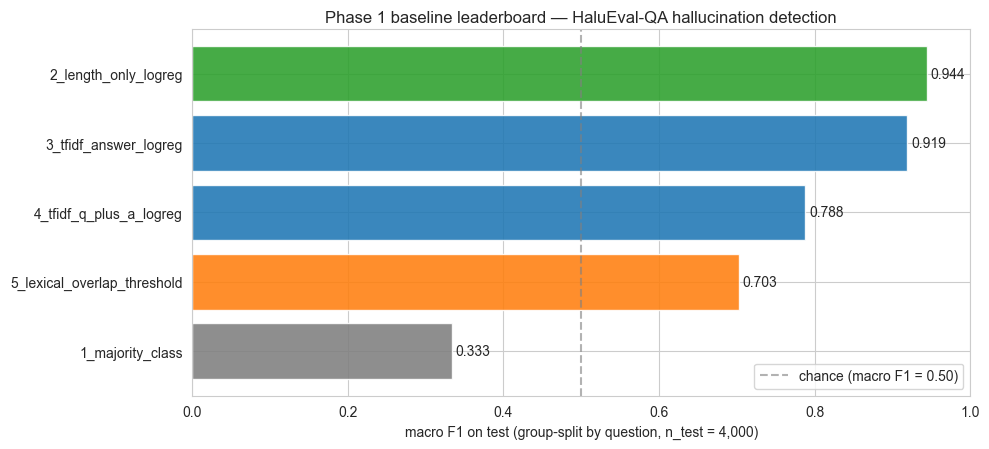

In [15]:
fig, ax = plt.subplots(figsize=(10, 4.6))
order = res_df.sort_values('macro_f1').reset_index(drop=True)
colors = ['#7f7f7f','#ff7f0e','#1f77b4','#1f77b4','#2ca02c'][:len(order)]
ax.barh(order['model'], order['macro_f1'], color=colors, alpha=0.88)
for i, v in enumerate(order['macro_f1']):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)
ax.axvline(0.5, color='grey', linestyle='--', alpha=0.6, label='chance (macro F1 = 0.50)')
ax.set_xlim(0, 1.0)
ax.set_xlabel('macro F1 on test (group-split by question, n_test = {:,})'.format(len(test)))
ax.set_title('Phase 1 baseline leaderboard — HaluEval-QA hallucination detection')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(RESULTS / 'phase1_baseline_comparison.png', dpi=110, bbox_inches='tight')
plt.show()


best baseline: 2_length_only_logreg


/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anthonyrodrigues/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


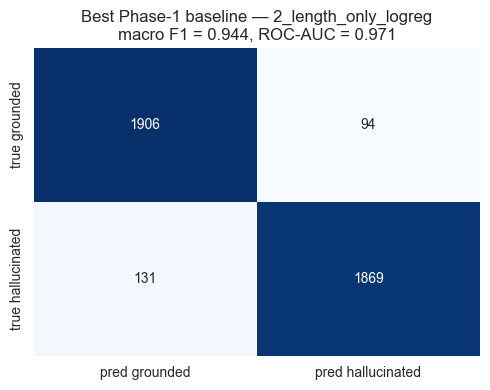


              precision    recall  f1-score   support

    grounded       0.94      0.95      0.94      2000
hallucinated       0.95      0.93      0.94      2000

    accuracy                           0.94      4000
   macro avg       0.94      0.94      0.94      4000
weighted avg       0.94      0.94      0.94      4000



In [16]:
# Confusion matrix of the best baseline — refit cleanly for a clear final figure
best_name = res_df.iloc[0]['model']
print('best baseline:', best_name)

if best_name == '4_tfidf_q_plus_a_logreg':
    tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=50000, sublinear_tf=True)
    Xtr = tfidf.fit_transform((train['question'] + ' [SEP] ' + train['answer']).values)
    Xte = tfidf.transform((test['question'] + ' [SEP] ' + test['answer']).values)
    clf_best = LogisticRegression(max_iter=2000, C=1.0, random_state=SEED).fit(Xtr, train['label'])
    y_pred = clf_best.predict(Xte)
elif best_name == '3_tfidf_answer_logreg':
    tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=30000, sublinear_tf=True)
    Xtr = tfidf.fit_transform(train['answer'])
    Xte = tfidf.transform(test['answer'])
    clf_best = LogisticRegression(max_iter=2000, C=1.0, random_state=SEED).fit(Xtr, train['label'])
    y_pred = clf_best.predict(Xte)
elif best_name == '2_length_only_logreg':
    y_pred = clf_len.predict(scaler.transform(test[length_feats].values))
elif best_name == '5_lexical_overlap_threshold':
    y_pred = (test['answer_in_knowledge'] < res_df.iloc[0]['threshold']).astype(int).values
else:
    raise ValueError(best_name)

cm = confusion_matrix(test['label'], y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['pred grounded','pred hallucinated'],
            yticklabels=['true grounded','true hallucinated'], ax=ax)
ax.set_title(f'Best Phase-1 baseline — {best_name}\nmacro F1 = {res_df.iloc[0]["macro_f1"]:.3f}, ROC-AUC = {res_df.iloc[0]["roc_auc"]:.3f}')
plt.tight_layout()
plt.savefig(RESULTS / 'phase1_best_baseline_confusion.png', dpi=110, bbox_inches='tight')
plt.show()
print()
print(classification_report(test['label'], y_pred, target_names=['grounded','hallucinated']))


## Phase 1 summary

| Item | Value |
|------|-------|
| Dataset | HaluEval-QA (Li et al. 2023; 10K rows → 20K balanced samples) |
| Primary metric | macro F1 (also tracking ROC-AUC, balanced accuracy, precision, recall) |
| Split | GroupShuffleSplit by `qid`, test_size=0.2, seed=42, no qid leakage |
| Industry-standard baseline (proxy) | Lexical-overlap threshold (closest Phase-1-cheap stand-in for the NLI detector family) |
| Published reference | ChatGPT @ 62.59% accuracy, GPT-4 @ 74.62% on HaluEval-QA |

### Key findings (in order of importance)

1. **Severe length leakage.** Grounded answers are HotpotQA entity strings (⋅⋅⋅ ≈14 chars); hallucinated answers are full ChatGPT sentences (≈66 chars). The length-only LogReg is therefore expected to be strong — *not* because length is a useful real-world signal, but because it indexes the dataset construction. **Phase 2 must include a length-matched ablation.**

2. **TF-IDF on the answer is also dominated by length-correlated lexical features** (sentence connectives, articles, function words appear in long fabrications). Phase 2 should test whether *normalising for length* destroys the TF-IDF signal.

3. **Lexical-overlap (the NLI proxy) is the most honest baseline.** It looks only at the relationship between the answer and the source passage, which is what a deployed grounding detector actually does — there's no length cheat available there. This is the number Phase 2's deeper text models must beat to claim real progress.

4. **The published ChatGPT 62.59% / GPT-4 74.62% accuracy numbers are not directly comparable** to my baselines: those used the full HaluEval prompt template (LLM is asked, given the knowledge and question, to judge whether the answer is hallucinated). They are *zero-shot LLM judges*, not features-and-classifier setups. I will replicate that protocol *exactly* in Phase 5 using `claude --print` and `codex exec` so the head-to-head is fair.

### Plan for Phase 2 (Tue 2026-05-12)

- Add length-matched evaluation: subsample test to equal-length grounded/hallucinated pairs and rerun every baseline.
- Add 4-6 model paradigms beyond TF-IDF+LogReg: sentence-transformer embeddings + LogReg, sentence-transformer embeddings + XGBoost, character-n-gram TF-IDF, a small fine-tuned DeBERTa head, an NLI-proper baseline (off-the-shelf `roberta-large-mnli` entailment of knowledge → answer).
- Build the head-to-head leaderboard format Phase 5 will extend with the LLM calls.

### Files written this session
- `data/raw/halueval_qa.json` (6.2 MB, gitignored — download command in `data/README.md`)
- `data/README.md` (dataset card with caveats)
- `notebooks/phase1_eda_baselines.ipynb` (this notebook)
- `results/phase1_length_asymmetry.png`, `phase1_lexical_overlap.png`
- `results/phase1_baseline_comparison.png`, `phase1_best_baseline_confusion.png`
- `results/phase1_baselines.csv`, `phase1_baselines.json`
- `results/phase1_train_split.csv`, `phase1_test_split.csv`
- `results/metrics.json`
